<a href="https://colab.research.google.com/github/padmacharan-123/AAI-LAB/blob/main/AAI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Cell 1: Install & import everything ──────────────────────────
# TensorFlow comes pre-installed in Colab. Just run this cell.

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import copy, random, warnings
warnings.filterwarnings('ignore')

# Fix random seeds so results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.19.0
All libraries loaded successfully!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total clients      : 5
Samples per client : 12000
Test set size      : 10000
Image shape        : (28, 28, 1)


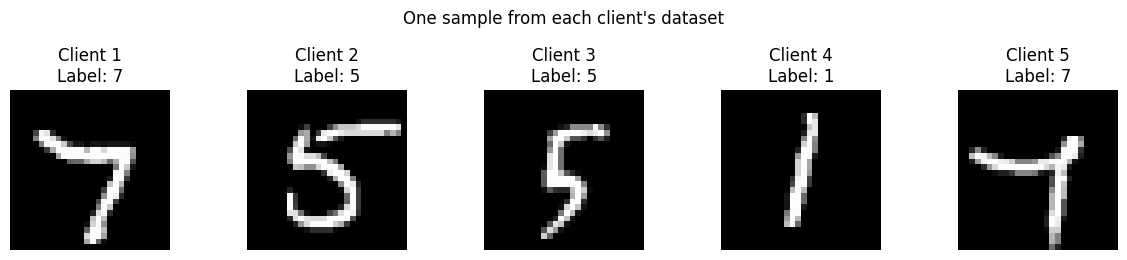

In [ ]:
# ── Cell 2: CNN model and data loading ───────────────────────────

# --- 2A. Build the CNN ---
def build_cnn():
    """
    A small Convolutional Neural Network for MNIST digit classification.
    Input:  28×28 grayscale image
    Output: probability over 10 digit classes (0–9)
    """
    model = keras.Sequential([
        # Layer 1: detect simple features (edges, curves)
        layers.Conv2D(32, (3,3), activation='relu',
                      padding='same', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),          # shrink from 28×28 → 14×14

        # Layer 2: detect complex features
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),          # shrink 14×14 → 7×7

        # Flatten + classify
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),                # prevent overfitting
        layers.Dense(10, activation='softmax')  # 10 digit classes
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- 2B. Load and partition MNIST ---
def load_and_split_data(num_clients=5):
    """
    Downloads MNIST (60,000 training images) and splits it
    equally among clients. Each client gets its own private shard.
    Returns:
      client_data  - list of (x_train, y_train) per client
      test_data    - shared (x_test, y_test) for global evaluation
    """
    # Load from Keras (auto-downloads first time)
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    # Normalise pixel values: 0–255 → 0.0–1.0
    x_train = x_train.astype('float32') / 255.0
    x_test  = x_test.astype('float32')  / 255.0

    # Add channel dimension: (N,28,28) → (N,28,28,1)
    x_train = x_train[..., np.newaxis]
    x_test  = x_test[...,  np.newaxis]

    # Shuffle before splitting
    idx = np.random.permutation(len(x_train))
    x_train, y_train = x_train[idx], y_train[idx]

    # Split into equal shards
    shard_size = len(x_train) // num_clients
    client_data = []
    for i in range(num_clients):
        start = i * shard_size
        end   = start + shard_size
        client_data.append((
            x_train[start:end],
            y_train[start:end]
        ))

    return client_data, (x_test, y_test)

# --- Test it ---
NUM_CLIENTS = 5
client_data, test_data = load_and_split_data(NUM_CLIENTS)

print(f"Total clients      : {NUM_CLIENTS}")
print(f"Samples per client : {len(client_data[0][0])}")
print(f"Test set size      : {len(test_data[0])}")
print(f"Image shape        : {client_data[0][0][0].shape}")

# Visualise a few samples
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(client_data[i][0][0].squeeze(), cmap='gray')
    ax.set_title(f"Client {i+1}\nLabel: {client_data[i][1][0]}")
    ax.axis('off')
plt.suptitle("One sample from each client's dataset", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 3: FL client class and FedAvg aggregation ───────────────

# --- 3A. Label-flip attack helper ---
def apply_label_flip(y, source=1, target=7):
    """
    Attack: replace all 'source' labels with 'target'.
    Default: turn every '1' into a '7'.
    This corrupts the local dataset without changing the images.
    """
    y_corrupt = y.copy()
    y_corrupt[y_corrupt == source] = target
    return y_corrupt

# --- 3B. Client class ---
class FederatedClient:
    """
    Represents one device participating in Federated Learning.
    - Honest clients train normally on their data shard.
    - Malicious clients flip labels before training (attack).
    """

    def __init__(self, client_id, data, is_malicious=False):
        self.id           = client_id
        self.x, self.y    = data          # local private dataset
        self.is_malicious = is_malicious
        self.model        = None          # will be set each round

    def receive_global_weights(self, weights):
        """Download the latest global model."""
        if self.model is None:
            self.model = build_cnn()
        self.model.set_weights(weights)

    def local_train(self, epochs=2, batch_size=64):
        """
        Train on local data and return the updated weights.
        Malicious clients corrupt their labels first.
        """
        y_train = self.y

        if self.is_malicious:
            y_train = apply_label_flip(self.y)
            # (the server can't see this — it only gets the weights back)

        history = self.model.fit(
            self.x, y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0          # silent — no output spam
        )

        return {
            'client_id':    self.id,
            'weights':      self.model.get_weights(),
            'loss':         history.history['loss'][-1],
            'is_malicious': self.is_malicious
        }

# --- 3C. FedAvg aggregation ---
def fed_avg(accepted_updates, data_sizes):
    """
    Federated Averaging (McMahan et al., 2017).

    Formula:  w_global = Σ (n_k / n_total) × w_k
      where n_k   = number of samples client k has
            w_k   = client k's weight update
            n_total = sum of all accepted clients' sample counts

    This means clients with more data have more influence.
    """
    if not accepted_updates:
        raise ValueError("No updates to aggregate!")

    # Get dataset sizes of accepted clients only
    accepted_ids = [u['client_id'] for u in accepted_updates]
    sizes        = [data_sizes[i] for i in accepted_ids]
    total        = sum(sizes)

    # Weighted average, layer by layer
    avg_weights = []
    num_layers  = len(accepted_updates[0]['weights'])

    for layer_idx in range(num_layers):
        layer_avg = np.zeros_like(accepted_updates[0]['weights'][layer_idx])
        for update, size in zip(accepted_updates, sizes):
            layer_avg += (size / total) * update['weights'][layer_idx]
        avg_weights.append(layer_avg)

    return avg_weights

# --- 3D. Weight deviation metric ---
def compute_deviation(update_weights, global_weights):
    """
    Measure how far a client's update is from the global model.
    Large deviation = potential malicious client.
    Uses L2 norm averaged across all layers.
    """
    deviations = [
        np.linalg.norm(u - g)
        for u, g in zip(update_weights, global_weights)
    ]
    return float(np.mean(deviations))

# --- Test it ---
data_sizes = [len(client_data[i][0]) for i in range(NUM_CLIENTS)]

# Create 5 clients (clients 3 and 4 are malicious)
MALICIOUS_IDS = [2, 3]   # 0-indexed
clients = [
    FederatedClient(i, client_data[i], is_malicious=(i in MALICIOUS_IDS))
    for i in range(NUM_CLIENTS)
]

print("Clients created:")
for c in clients:
    status = "MALICIOUS (label-flipper)" if c.is_malicious else "Honest"
    print(f"  Client {c.id + 1}: {status}  |  {len(c.x)} samples")

Clients created:
  Client 1: Honest  |  12000 samples
  Client 2: Honest  |  12000 samples
  Client 3: MALICIOUS (label-flipper)  |  12000 samples
  Client 4: MALICIOUS (label-flipper)  |  12000 samples
  Client 5: Honest  |  12000 samples


In [ ]:
# ── Cell 4: Q-learning RL agent ───────────────────────────────────

class QLearningAgent:
    """
    A Reinforcement Learning agent that decides whether to
    ACCEPT or REJECT each client's update every round.

    State  : (loss_bucket, deviation_bucket) — discretised metrics
    Action : 0 = reject the client, 1 = accept the client
    Reward : positive if global accuracy improves, negative otherwise
    """

    # Bin boundaries for discretising continuous state values
    # e.g. a loss of 0.8 falls in bucket 1 (between 0.5 and 1.0)
    LOSS_BINS = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, np.inf]
    DEV_BINS  = [0.0, 0.1, 0.3, 0.6, 1.0, 2.0, np.inf]

    N_LOSS = 6   # number of loss buckets
    N_DEV  = 6   # number of deviation buckets
    N_ACT  = 2   # actions: reject(0) or accept(1)

    def __init__(self, alpha=0.1, gamma=0.9,
                 epsilon=0.4, epsilon_decay=0.99, epsilon_min=0.05):
        """
        alpha        : learning rate (how fast Q-values update)
        gamma        : discount factor (how much future rewards matter)
        epsilon      : exploration rate (random action probability)
        epsilon_decay: multiply epsilon by this each round
        epsilon_min  : floor for epsilon (always explore a little)
        """
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min

        # Q-table: shape = (loss_buckets, dev_buckets, actions)
        # Start with small random values to break ties
        self.Q = np.random.uniform(-0.01, 0.01,
                                   (self.N_LOSS, self.N_DEV, self.N_ACT))

        # Log every decision for analysis
        self.log = []

    def _discretise(self, loss, deviation):
        """Map (loss, deviation) → (bucket_index, bucket_index)."""
        def bucket(val, bins):
            for i, b in enumerate(bins[1:], 1):
                if val < b:
                    return i - 1
            return len(bins) - 2

        return bucket(loss, self.LOSS_BINS), bucket(deviation, self.DEV_BINS)

    def choose_action(self, loss, deviation):
        """
        ε-greedy policy:
          - with probability ε: pick a random action (explore)
          - otherwise: pick the action with the highest Q-value (exploit)
        """
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.N_ACT)

        state = self._discretise(loss, deviation)
        return int(np.argmax(self.Q[state]))

    def update_q(self, loss, deviation, action,
                 reward, next_loss=0.0, next_dev=0.0):
        """
        Bellman equation update:
          Q(s,a) ← Q(s,a) + α × [r + γ × max_a' Q(s',a') − Q(s,a)]

        In plain English:
          "Adjust the Q-value toward the actual reward received
           plus the discounted best future reward."
        """
        s  = self._discretise(loss, deviation)
        s_ = self._discretise(next_loss, next_dev)

        current_q  = self.Q[s][action]
        best_next  = np.max(self.Q[s_])
        target     = reward + self.gamma * best_next
        self.Q[s][action] = current_q + self.alpha * (target - current_q)

    def compute_reward(self, prev_acc, curr_acc):
        """
        Reward signal based on how accuracy changed this round.
          +1  (and bonus) if accuracy improved
          −1  (and penalty) if accuracy dropped
        """
        delta = curr_acc - prev_acc
        if delta > 0:
            return 1.0 + delta * 10
        elif delta < 0:
            return -1.0 + delta * 10
        return 0.0

    def decay_epsilon(self):
        """Reduce exploration rate after each round."""
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

    def record(self, rnd, client_id, action, loss, dev, is_malicious):
        """Save this decision to the log."""
        self.log.append({
            'round':        rnd,
            'client':       client_id + 1,
            'action':       'accept' if action == 1 else 'reject',
            'loss':         round(loss, 4),
            'deviation':    round(dev, 4),
            'is_malicious': is_malicious,
            'correct':      (is_malicious and action == 0) or
                            (not is_malicious and action == 1)
        })

    def print_summary(self):
        """Print detection accuracy statistics."""
        total    = len(self.log)
        if total == 0:
            return

        true_pos  = sum(1 for d in self.log if d['is_malicious']     and d['action']=='reject')
        false_pos = sum(1 for d in self.log if not d['is_malicious'] and d['action']=='reject')
        true_neg  = sum(1 for d in self.log if not d['is_malicious'] and d['action']=='accept')
        false_neg = sum(1 for d in self.log if d['is_malicious']     and d['action']=='accept')

        precision = true_pos / max(true_pos + false_pos, 1)
        recall    = true_pos / max(true_pos + false_neg, 1)
        f1        = 2 * precision * recall / max(precision + recall, 1e-9)

        print("\n===== RL Agent Detection Results =====")
        print(f"  True  Positives (malicious caught) : {true_pos}")
        print(f"  False Positives (honest rejected)  : {false_pos}")
        print(f"  True  Negatives (honest accepted)  : {true_neg}")
        print(f"  False Negatives (malicious missed) : {false_neg}")
        print(f"  Precision : {precision:.3f}")
        print(f"  Recall    : {recall:.3f}")
        print(f"  F1 Score  : {f1:.3f}")
        print(f"  Final ε   : {self.epsilon:.4f}")
        print("======================================")

print("RL Agent class defined.")
print("\nHow it works:")
print("  State  = (loss_bucket, deviation_bucket)")
print("  Action = 0 (reject) or 1 (accept)")
print("  Reward = +1+bonus if accuracy improved, -1-penalty if dropped")
print("  Q-table shape:", (6, 6, 2))

RL Agent class defined.

How it works:
  State  = (loss_bucket, deviation_bucket)
  Action = 0 (reject) or 1 (accept)
  Reward = +1+bonus if accuracy improved, -1-penalty if dropped
  Q-table shape: (6, 6, 2)


In [ ]:
# ── Cell 5: Main federated learning simulation ───────────────────

def run_fl_scenario(scenario_name, client_data, test_data,
                    with_attack=False, with_rl=False,
                    num_rounds=15, local_epochs=2):
    """
    Run one complete FL scenario for num_rounds communication rounds.

    Parameters:
      scenario_name : label for this run
      with_attack   : if True, malicious clients flip labels
      with_rl       : if True, RL agent filters client updates
      num_rounds    : number of communication rounds
      local_epochs  : how many epochs each client trains per round

    Returns:
      dict with accuracy and loss history per round
    """

    NUM_CLIENTS   = len(client_data)
    MALICIOUS_IDS = [2, 3] if with_attack else []
    data_sizes    = [len(d[0]) for d in client_data]

    print(f"\n{'='*50}")
    print(f"  Scenario : {scenario_name}")
    print(f"  Attack   : {with_attack}   |   RL Defense : {with_rl}")
    print(f"  Rounds   : {num_rounds}    |   Epochs/round: {local_epochs}")
    print(f"{'='*50}")

    # ── Initialise global model ────────────────────────────────
    global_model = build_cnn()

    # ── Create clients ─────────────────────────────────────────
    clients = [
        FederatedClient(i, client_data[i],
                        is_malicious=(i in MALICIOUS_IDS))
        for i in range(NUM_CLIENTS)
    ]

    # ── Create RL agent (only for defended scenario) ───────────
    agent = QLearningAgent() if with_rl else None

    # ── History tracking ───────────────────────────────────────
    acc_history  = []
    loss_history = []
    prev_acc     = 0.0

    # ── Communication rounds ───────────────────────────────────
    for rnd in range(1, num_rounds + 1):

        # [1] Broadcast: send current global weights to all clients
        global_weights = global_model.get_weights()

        # [2] Local training: each client trains on its private data
        updates = []
        for client in clients:
            client.receive_global_weights(global_weights)
            update = client.local_train(
                epochs=local_epochs, batch_size=64
            )
            # Add deviation score (used by RL agent)
            update['deviation'] = compute_deviation(
                update['weights'], global_weights
            )
            updates.append(update)

        # [3] Client selection
        if with_rl and agent:
            # RL agent evaluates each update and decides accept/reject
            accepted = []
            for u in updates:
                action = agent.choose_action(u['loss'], u['deviation'])
                agent.record(rnd, u['client_id'], action,
                             u['loss'], u['deviation'], u['is_malicious'])
                if action == 1:
                    accepted.append(u)

            # Safety: if agent rejects everyone, fall back to accepting all
            if len(accepted) == 0:
                accepted = updates

        else:
            # No defense: accept every client unconditionally
            accepted = updates

        # [4] FedAvg: aggregate accepted updates into new global weights
        new_weights = fed_avg(accepted, data_sizes)
        global_model.set_weights(new_weights)

        # [5] Evaluate global model on shared test set
        loss, acc = global_model.evaluate(
            test_data[0], test_data[1], verbose=0
        )
        acc_history.append(round(float(acc), 4))
        loss_history.append(round(float(loss), 4))

        # [6] RL reward and Q-table update
        if with_rl and agent:
            reward = agent.compute_reward(prev_acc, acc)
            for u in updates:
                was_accepted = any(
                    a['client_id'] == u['client_id'] for a in accepted
                )
                action_taken = 1 if was_accepted else 0
                agent.update_q(u['loss'], u['deviation'],
                               action_taken, reward)
            agent.decay_epsilon()

        prev_acc = acc

        # Print round summary
        n_acc = len(accepted)
        n_rej = NUM_CLIENTS - n_acc
        print(f"  Round {rnd:>2} | acc={acc:.4f} | loss={loss:.4f} "
              f"| accepted={n_acc}  rejected={n_rej}")

    if with_rl and agent:
        agent.print_summary()

    return {
        'scenario':    scenario_name,
        'accuracy':    acc_history,
        'loss':        loss_history,
        'rounds':      list(range(1, num_rounds + 1)),
        'agent':       agent
    }


# ── Run all 3 scenarios ────────────────────────────────────────────
NUM_ROUNDS    = 15
LOCAL_EPOCHS  = 2

print("Starting federated learning simulation...")
print("This will take several minutes. Please wait.\n")

# Scenario 1: Normal FL (baseline — no attack, no defense)
result_normal = run_fl_scenario(
    scenario_name = "Normal FL",
    client_data   = client_data,
    test_data     = test_data,
    with_attack   = False,
    with_rl       = False,
    num_rounds    = NUM_ROUNDS,
    local_epochs  = LOCAL_EPOCHS
)

# Scenario 2: Attacked FL (no defense — shows damage)
result_attacked = run_fl_scenario(
    scenario_name = "Attacked FL",
    client_data   = client_data,
    test_data     = test_data,
    with_attack   = True,
    with_rl       = False,
    num_rounds    = NUM_ROUNDS,
    local_epochs  = LOCAL_EPOCHS
)

# Scenario 3: Defended FL (attack + RL defense — shows recovery)
result_defended = run_fl_scenario(
    scenario_name = "Defended FL (RL)",
    client_data   = client_data,
    test_data     = test_data,
    with_attack   = True,
    with_rl       = True,
    num_rounds    = NUM_ROUNDS,
    local_epochs  = LOCAL_EPOCHS
)

print("\n\nAll 3 scenarios complete!")

Starting federated learning simulation...
This will take several minutes. Please wait.


  Scenario : Normal FL
  Attack   : False   |   RL Defense : False
  Rounds   : 15    |   Epochs/round: 2
  Round  1 | acc=0.9735 | loss=0.1098 | accepted=5  rejected=0
  Round  2 | acc=0.9857 | loss=0.0457 | accepted=5  rejected=0
  Round  3 | acc=0.9884 | loss=0.0343 | accepted=5  rejected=0
  Round  4 | acc=0.9904 | loss=0.0297 | accepted=5  rejected=0
  Round  5 | acc=0.9911 | loss=0.0263 | accepted=5  rejected=0
  Round  6 | acc=0.9914 | loss=0.0265 | accepted=5  rejected=0
  Round  7 | acc=0.9928 | loss=0.0232 | accepted=5  rejected=0
  Round  8 | acc=0.9925 | loss=0.0233 | accepted=5  rejected=0
  Round  9 | acc=0.9929 | loss=0.0230 | accepted=5  rejected=0
  Round 10 | acc=0.9920 | loss=0.0240 | accepted=5  rejected=0
  Round 11 | acc=0.9935 | loss=0.0224 | accepted=5  rejected=0
  Round 12 | acc=0.9931 | loss=0.0233 | accepted=5  rejected=0
  Round 13 | acc=0.9932 | loss=0.0225 | accepted=

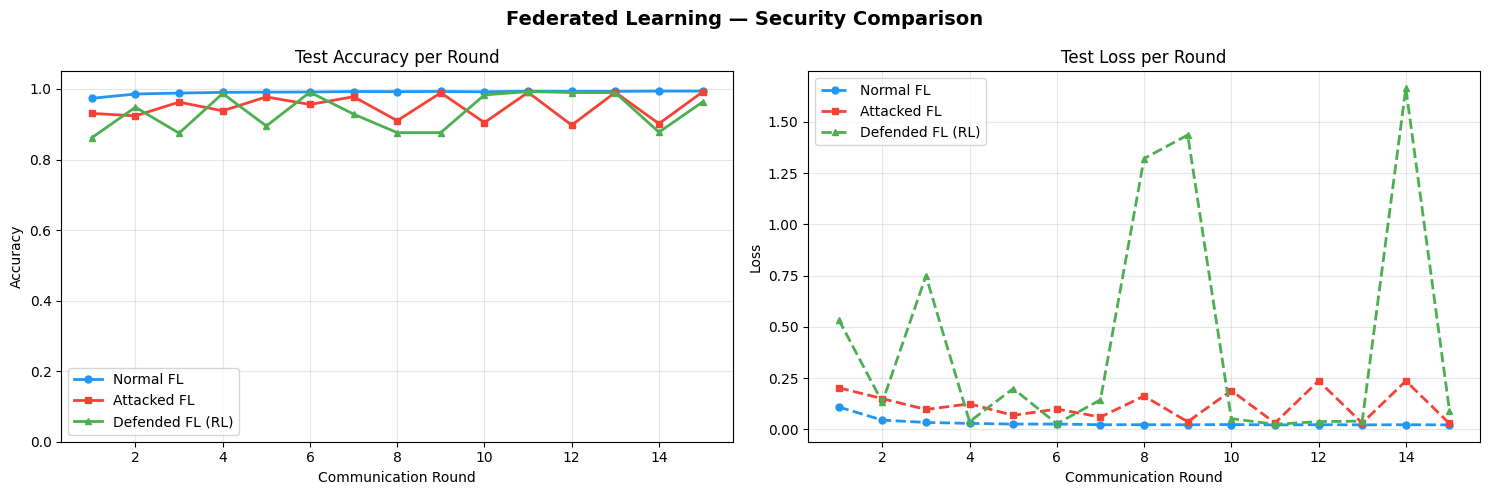

Chart saved as fl_comparison.png


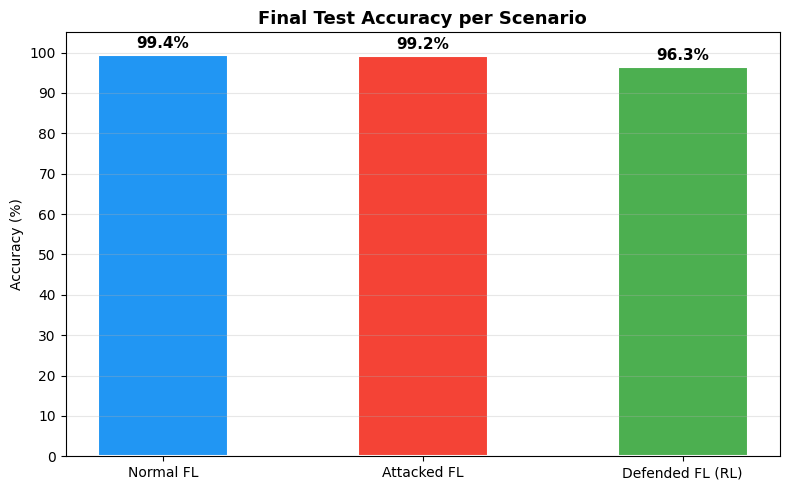


SCENARIO                    FINAL ACC  FINAL LOSS
-------------------------------------------------------
  Normal FL                    99.40%      0.0224
  Attacked FL                  99.16%      0.0292
  Defended FL (RL)             96.31%      0.0924

  Attack degradation : -0.24%  (Normal vs Attacked)
  RL recovery        : +-2.85%  (Attacked vs Defended)
  Gap remaining      : -3.09%  (Normal vs Defended)


In [ ]:
# ── Cell 6: Visualise accuracy and loss comparison ───────────────

results = [result_normal, result_attacked, result_defended]
colors  = {
    'Normal FL':         '#2196F3',  # blue
    'Attacked FL':       '#F44336',  # red
    'Defended FL (RL)':  '#4CAF50',  # green
}
markers = {
    'Normal FL':         'o',
    'Attacked FL':       's',
    'Defended FL (RL)':  '^',
}

# ── Plot 1: Accuracy and Loss side by side ────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Federated Learning — Security Comparison', fontsize=14, fontweight='bold')

for res in results:
    name = res['scenario']
    r    = res['rounds']
    ax1.plot(r, res['accuracy'], label=name, color=colors[name],
             marker=markers[name], markersize=5, linewidth=2)
    ax2.plot(r, res['loss'],     label=name, color=colors[name],
             marker=markers[name], markersize=5, linewidth=2, linestyle='--')

ax1.set_title('Test Accuracy per Round',  fontsize=12)
ax1.set_xlabel('Communication Round')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title('Test Loss per Round', fontsize=12)
ax2.set_xlabel('Communication Round')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as fl_comparison.png")

# ── Plot 2: Final accuracy bar chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
names   = [r['scenario'] for r in results]
finals  = [r['accuracy'][-1] * 100 for r in results]
bars = ax.bar(names, finals,
              color=[colors[n] for n in names],
              width=0.5, edgecolor='white', linewidth=1.5)

ax.set_title('Final Test Accuracy per Scenario', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_yticks(range(0, 110, 10))

for bar, val in zip(bars, finals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fl_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print final summary table ─────────────────────────────────────
print("\n" + "="*55)
print(f"{'SCENARIO':<25}  {'FINAL ACC':>10}  {'FINAL LOSS':>10}")
print("-"*55)
for res in results:
    final_acc  = res['accuracy'][-1]
    final_loss = res['loss'][-1]
    print(f"  {res['scenario']:<23}  {final_acc*100:>9.2f}%  {final_loss:>10.4f}")
print("="*55)

# Show accuracy degradation from attack
normal_acc   = result_normal['accuracy'][-1]
attacked_acc = result_attacked['accuracy'][-1]
defended_acc = result_defended['accuracy'][-1]
degradation  = (normal_acc - attacked_acc) * 100
recovery     = (defended_acc - attacked_acc) * 100

print(f"\n  Attack degradation : -{degradation:.2f}%  (Normal vs Attacked)")
print(f"  RL recovery        : +{recovery:.2f}%  (Attacked vs Defended)")
print(f"  Gap remaining      : -{(normal_acc - defended_acc)*100:.2f}%  (Normal vs Defended)")